In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n_samples = 1_000_000
Age = np.random.randint(18, 65, n_samples)

data = {
    'Age': Age,
    'BusinessTravel': np.random.choice(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel'], n_samples, p=[0.6, 0.25, 0.15]),
    'DailyRate': np.random.randint(100, 1500, n_samples),
    'Department': np.random.choice(['Sales', 'Research & Development', 'Human Resources'], n_samples, p=[0.3, 0.6, 0.1]),
    'DistanceFromHome': np.random.randint(1, 30, n_samples),
    'Education': np.random.randint(1, 5, n_samples),
    'EducationField': np.random.choice(['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources'], n_samples),
    'EmployeeCount': np.ones(n_samples, dtype=int),
    'EmployeeNumber': np.arange(1, n_samples + 1),
    'EnvironmentSatisfaction': np.random.randint(1, 5, n_samples),
    'Gender': np.random.choice(['Female', 'Male'], n_samples),
    'HourlyRate': np.random.randint(30, 100, n_samples),
    'JobInvolvement': np.random.randint(1, 5, n_samples),
    'JobLevel': np.random.randint(1, 6, n_samples),
    'JobRole': np.random.choice(['Sales Executive', 'Research Scientist', 'Laboratory Technician',
                                'Manufacturing Director', 'Healthcare Representative', 'Manager',
                                'Sales Representative', 'Research Director', 'Human Resources'], n_samples),
    'JobSatisfaction': np.random.randint(1, 5, n_samples),
    'MaritalStatus': np.random.choice(['Single', 'Married', 'Divorced'], n_samples),
    'MonthlyIncome': np.random.randint(1000, 20000, n_samples),
    'MonthlyRate': np.random.randint(2000, 27000, n_samples),
    'NumCompaniesWorked': np.random.randint(0, 10, n_samples),
    'Over18': ['Y'] * n_samples,
    'OverTime': np.random.choice(['Yes', 'No'], n_samples, p=[0.28, 0.72]),
    'PercentSalaryHike': np.random.randint(11, 26, n_samples),
    'PerformanceRating': np.random.choice([3, 4], n_samples, p=[0.84, 0.16]),
    'RelationshipSatisfaction': np.random.randint(1, 5, n_samples),
    'StandardHours': [80] * n_samples,
    'StockOptionLevel': np.random.randint(0, 4, n_samples),
    'TotalWorkingYears': np.array([np.random.randint(0, max(age - 16, 1)) for age in Age]),
    'TrainingTimesLastYear': np.random.randint(0, 7, n_samples),
    'WorkLifeBalance': np.random.randint(1, 5, n_samples),
    'YearsAtCompany': np.random.randint(0, 40, n_samples),
    'YearsInCurrentRole': np.random.randint(0, 19, n_samples),
    'YearsSinceLastPromotion': np.random.randint(0, 16, n_samples),
    'YearsWithCurrManager': np.random.randint(0, 18, n_samples),
}

df = pd.DataFrame(data)
df.loc[df['YearsAtCompany'] < df['YearsInCurrentRole'], 'YearsInCurrentRole'] = df['YearsAtCompany']
df.loc[df['YearsAtCompany'] < df['YearsSinceLastPromotion'], 'YearsSinceLastPromotion'] = df['YearsAtCompany']
df.loc[df['TotalWorkingYears'] < df['YearsAtCompany'], 'TotalWorkingYears'] = df['YearsAtCompany']

risk_score = (
    (df['OverTime'] == 'Yes').astype(int) * 1.2 +
    (df['JobSatisfaction'] <= 2).astype(int) * 1.0 +
    (df['EnvironmentSatisfaction'] <= 2).astype(int) * 0.8 +
    (df['WorkLifeBalance'] <= 2).astype(int) * 0.9 +
    (df['MonthlyIncome'] < 4000).astype(int) * 1.1 +
    (df['DistanceFromHome'] > 15).astype(int) * 0.6 +
    (df['YearsSinceLastPromotion'] > 5).astype(int) * 0.7 +
    (df['NumCompaniesWorked'] > 4).astype(int) * 0.5 +
    (df['Age'] < 30).astype(int) * 0.5 +
    (df['BusinessTravel'] == 'Travel_Frequently').astype(int) * 0.4 -
    (df['StockOptionLevel'] > 0).astype(int) * 0.5 -
    (df['YearsAtCompany'] > 10).astype(int) * 0.6
)
probability = 1 / (1 + np.exp(-(risk_score - 4.2)))
df['Attrition'] = np.where(np.random.random(n_samples) < probability, 'Yes', 'No')

df_processed = df.copy()
df_processed['IncomePerYear'] = df_processed['MonthlyIncome'] / (df_processed['TotalWorkingYears'] + 1)
satisfaction_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction']
df_processed['TotalSatisfaction'] = df_processed[satisfaction_cols].mean(axis=1)
df_processed['PromotionRate'] = df_processed['YearsSinceLastPromotion'] / (df_processed['YearsAtCompany'] + 1)
df_processed['LongTimeNoPromotion'] = (df_processed['YearsSinceLastPromotion'] > 5).astype(int)
df_processed['AgeStartedWorking'] = df_processed['Age'] - df_processed['TotalWorkingYears']
df_processed['AgeStartedWorking'] = df_processed.loc[df_processed['AgeStartedWorking'] > 14, 'AgeStartedWorking']
df_processed['YearsInOtherCompanies'] = df_processed['TotalWorkingYears'] - df_processed['YearsAtCompany']
df_processed['CompanyChangeRate'] = df_processed['NumCompaniesWorked'] / (df_processed['TotalWorkingYears'] + 1)
df_processed['OverworkRisk'] = ((df_processed['OverTime'] == 'Yes') & (df_processed['WorkLifeBalance'] <= 2)).astype(int)
df_processed['AgeGroup'] = pd.cut(df_processed['Age'], bins=[17, 25, 35, 45, 55, 65], labels=['18-25', '26-35', '36-45', '46-55', '56-65'])
df_processed['RoleStability'] = df_processed['YearsInCurrentRole'] / (df_processed['YearsAtCompany'] + 1)
df_processed['EngagementScore'] = (df_processed['JobInvolvement'] + df_processed['JobSatisfaction'] + df_processed['PerformanceRating']) / 3

df_processed['Attrition'] = df_processed['Attrition'].map({'Yes': 1, 'No': 0})
df_processed.dropna(subset='AgeStartedWorking', inplace=True)

print(f"Dataset final: {df_processed.shape}")
print(f"Taxa de Attrition: {df_processed['Attrition'].mean()*100:.2f}%")

Dataset final: (645977, 46)
Taxa de Attrition: 16.43%


In [0]:
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_processed = df_processed.drop(columns=cols_to_drop)

numeric_features = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features.remove('Attrition')
categorical_features = df_processed.select_dtypes(include=['object', 'category']).columns.tolist()

df_encoded = pd.get_dummies(df_processed, columns=categorical_features, prefix=categorical_features)

X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

Treino: (516781, 66) | Teste: (129196, 66)


In [0]:
%pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Balanceado: {X_train_balanced.shape}, classe 1 = {(y_train_balanced==1).sum()}")

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Balanceado: (863706, 66), classe 1 = 431853


In [0]:
%pip install xgboost lightgbm imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.3/303.3 MB 124.2 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=15, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, n_jobs=1)
}

print("Avaliando modelos...")
initial_results = []
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\nTreinando {name}...")
    cv_n_jobs = 1 if name in ['LightGBM', 'Random Forest'] else -1

    cv_score = cross_val_score(model, X_train_balanced, y_train_balanced,
                               cv=skf, scoring='roc_auc', n_jobs=cv_n_jobs)
    model.fit(X_train_balanced, y_train_balanced)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)

    initial_results.append({
        'Model': name,
        'CV_ROC_AUC_Mean': cv_score.mean(),
        'CV_ROC_AUC_Std': cv_score.std(),
        'Test_ROC_AUC': roc_auc,
        'Test_F1_Score': f1
    })

    print(f"CV ROC-AUC: {cv_score.mean():.4f} (+/- {cv_score.std():.4f})")
    print(f"Test ROC-AUC: {roc_auc:.4f} | F1: {f1:.4f}")

results_df = pd.DataFrame(initial_results).sort_values('Test_ROC_AUC', ascending=False)
print("\n=== RESULTADOS INICIAIS ===")
print(results_df)

top_models = results_df.head(3)['Model'].tolist()
print(f"\nTop 3 modelos: {top_models}")

Avaliando modelos...

Treinando Logistic Regression...


I0000 00:00:1782267659.014516    9388 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1782267659.175656    9388 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1782267659.239922    9388 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1782267659.326117    9388 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1782267659.447364    9388 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the docume

CV ROC-AUC: 0.8640 (+/- 0.0087)
Test ROC-AUC: 0.6847 | F1: 0.3551

Treinando Decision Tree...
CV ROC-AUC: 0.9292 (+/- 0.0005)
Test ROC-AUC: 0.7457 | F1: 0.3189

Treinando Random Forest...
CV ROC-AUC: 0.9529 (+/- 0.0004)
Test ROC-AUC: 0.7620 | F1: 0.2662

Treinando XGBoost...
CV ROC-AUC: 0.9565 (+/- 0.0003)
Test ROC-AUC: 0.7826 | F1: 0.2929

Treinando LightGBM...
CV ROC-AUC: 0.9572 (+/- 0.0003)
Test ROC-AUC: 0.7856 | F1: 0.2734

=== RESULTADOS INICIAIS ===
                 Model  CV_ROC_AUC_Mean  ...  Test_ROC_AUC  Test_F1_Score
4             LightGBM         0.957239  ...      0.785580       0.273360
3              XGBoost         0.956489  ...      0.782559       0.292898
2        Random Forest         0.952892  ...      0.762000       0.266183
1        Decision Tree         0.929189  ...      0.745743       0.318871
0  Logistic Regression         0.863973  ...      0.684677       0.355116

[5 rows x 5 columns]

Top 3 modelos: ['LightGBM', 'XGBoost', 'Random Forest']


In [0]:
print("\nOtimizando hiperparâmetros dos top 3 modelos...")

param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'num_leaves': [31, 50, 100],
        'subsample': [0.7, 0.8, 0.9]
    }
}

optimized_models = {}

for model_name in top_models:
    print(f"\nOtimizando {model_name}...")
    search_n_jobs = 1 if model_name in ['LightGBM', 'Random Forest'] else -1

    model = models[model_name]
    random_search = RandomizedSearchCV(
        model,
        param_grids[model_name],
        n_iter=10,
        cv=3,
        scoring='roc_auc',
        n_jobs=search_n_jobs,
        random_state=42,
        verbose=1
    )

    random_search.fit(X_train_balanced, y_train_balanced)
    optimized_models[model_name] = random_search.best_estimator_

    print(f"Melhores parâmetros: {random_search.best_params_}")
    print(f"Melhor score CV: {random_search.best_score_:.4f}")

print("\nOtimização concluída!")


Otimizando hiperparâmetros dos top 3 modelos...

Otimizando LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhores parâmetros: {'subsample': 0.9, 'num_leaves': 50, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
Melhor score CV: 0.9346

Otimizando XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhores parâmetros: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Melhor score CV: 0.9354

Otimizando Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhores parâmetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Melhor score CV: 0.9463

Otimização concluída!


In [0]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve)

print("\nAvaliando modelos otimizados no conjunto de teste...")

optimized_results = []

for model_name, model in optimized_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)

    optimized_results.append({
        'Model': model_name,
        'Test_ROC_AUC': roc_auc,
        'Test_F1_Score': f1
    })

    print(f"\n{'='*40}")
    print(f"Modelo: {model_name}")
    print(f"ROC-AUC: {roc_auc:.4f} | F1: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Ficou', 'Saiu']))

optimized_results_df = pd.DataFrame(optimized_results).sort_values('Test_ROC_AUC', ascending=False)
print("\n=== RANKING FINAL (modelos otimizados) ===")
print(optimized_results_df)

best_model_name = optimized_results_df.iloc[0]['Model']
best_model = optimized_models[best_model_name]
print(f"\nMelhor modelo final: {best_model_name}")


Avaliando modelos otimizados no conjunto de teste...

Modelo: LightGBM
ROC-AUC: 0.7824 | F1: 0.2720
              precision    recall  f1-score   support

       Ficou       0.86      0.98      0.91    107964
        Saiu       0.61      0.18      0.27     21232

    accuracy                           0.85    129196
   macro avg       0.73      0.58      0.59    129196
weighted avg       0.82      0.85      0.81    129196


Modelo: XGBoost
ROC-AUC: 0.7703 | F1: 0.2927
              precision    recall  f1-score   support

       Ficou       0.86      0.97      0.91    107964
        Saiu       0.55      0.20      0.29     21232

    accuracy                           0.84    129196
   macro avg       0.71      0.58      0.60    129196
weighted avg       0.81      0.84      0.81    129196


Modelo: Random Forest
ROC-AUC: 0.7687 | F1: 0.2420
              precision    recall  f1-score   support

       Ficou       0.85      0.98      0.91    107964
        Saiu       0.58      0.15     

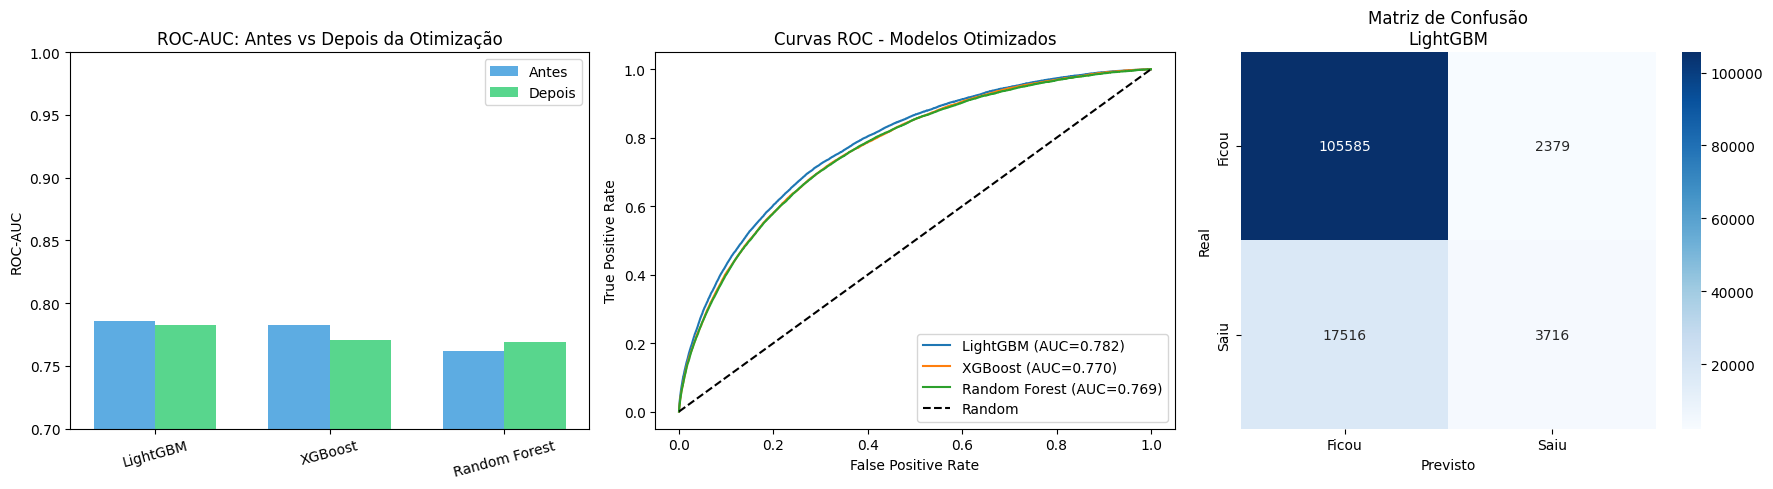

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Comparação ROC-AUC antes vs depois da otimização
models_names = [r['Model'] for r in optimized_results]
roc_before = [results_df[results_df['Model'] == m]['Test_ROC_AUC'].values[0] for m in models_names]
roc_after = [r['Test_ROC_AUC'] for r in optimized_results]

x = np.arange(len(models_names))
width = 0.35
axes[0].bar(x - width/2, roc_before, width, label='Antes', color='#3498db', alpha=0.8)
axes[0].bar(x + width/2, roc_after, width, label='Depois', color='#2ecc71', alpha=0.8)
axes[0].set_title('ROC-AUC: Antes vs Depois da Otimização')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_names, rotation=15)
axes[0].set_ylabel('ROC-AUC')
axes[0].legend()
axes[0].set_ylim(0.7, 1.0)

# Gráfico 2: Curvas ROC dos 3 modelos otimizados
for model_name, model in optimized_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_title('Curvas ROC - Modelos Otimizados')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Gráfico 3: Matriz de confusão do melhor modelo
best_y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Ficou', 'Saiu'], yticklabels=['Ficou', 'Saiu'])
axes[2].set_title(f'Matriz de Confusão\n{best_model_name}')
axes[2].set_xlabel('Previsto')
axes[2].set_ylabel('Real')

plt.tight_layout()
plt.show()

 Threshold  Precision   Recall       F1
      0.10   0.242912 0.887764 0.381451
      0.15   0.294203 0.780237 0.427289
      0.20   0.343929 0.670639 0.454680
      0.25   0.389063 0.565656 0.461028
      0.30   0.434887 0.469810 0.451674
      0.35   0.479509 0.383007 0.425859
      0.40   0.523210 0.305247 0.385556
      0.45   0.564390 0.232008 0.328838
      0.50   0.609680 0.175019 0.271965
      0.55   0.659804 0.123775 0.208447
      0.60   0.710243 0.083930 0.150120
      0.65   0.759840 0.053645 0.100216

Threshold ótimo (melhor F1): 0.25


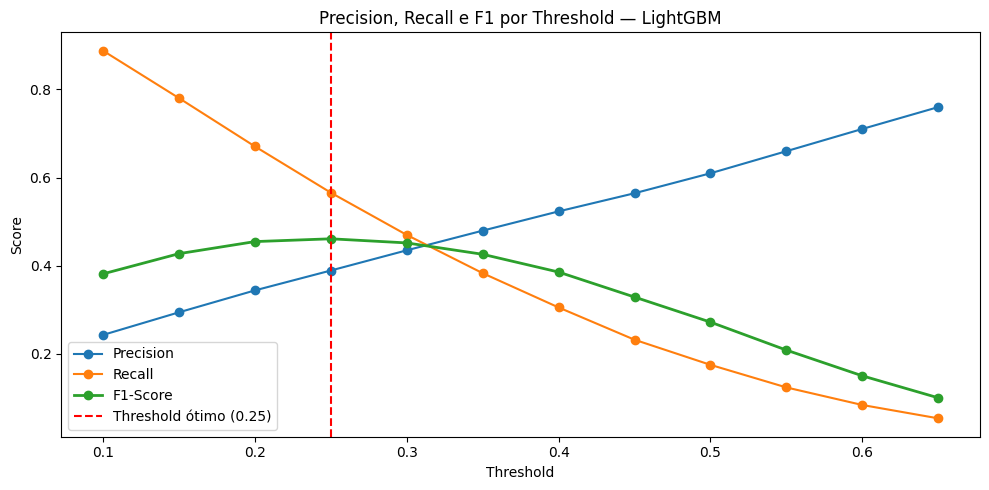


Resultado com threshold 0.25:
              precision    recall  f1-score   support

       Ficou       0.91      0.83      0.86    107964
        Saiu       0.39      0.57      0.46     21232

    accuracy                           0.78    129196
   macro avg       0.65      0.70      0.66    129196
weighted avg       0.82      0.78      0.80    129196



In [0]:
from sklearn.metrics import precision_recall_curve, f1_score, recall_score, precision_score

y_proba_best = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.7, 0.05)
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_best >= thresh).astype(int)
    threshold_results.append({
        'Threshold': thresh,
        'Precision': precision_score(y_test, y_pred_thresh, zero_division=0),
        'Recall': recall_score(y_test, y_pred_thresh),
        'F1': f1_score(y_test, y_pred_thresh, zero_division=0)
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

# Threshold ótimo = melhor F1
best_thresh = thresh_df.loc[thresh_df['F1'].idxmax(), 'Threshold']
print(f"\nThreshold ótimo (melhor F1): {best_thresh:.2f}")

# Visualização
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], label='Precision', marker='o')
ax.plot(thresh_df['Threshold'], thresh_df['Recall'], label='Recall', marker='o')
ax.plot(thresh_df['Threshold'], thresh_df['F1'], label='F1-Score', marker='o', linewidth=2)
ax.axvline(x=best_thresh, color='red', linestyle='--', label=f'Threshold ótimo ({best_thresh:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall e F1 por Threshold — LightGBM')
ax.legend()
plt.tight_layout()
plt.show()

# Resultado final com threshold ótimo
y_pred_optimal = (y_proba_best >= best_thresh).astype(int)
print(f"\nResultado com threshold {best_thresh:.2f}:")
print(classification_report(y_test, y_pred_optimal, target_names=['Ficou', 'Saiu']))

In [0]:
%pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 MB 175.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 97.4 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


Calculando valores SHAP (pode demorar alguns minutos)...


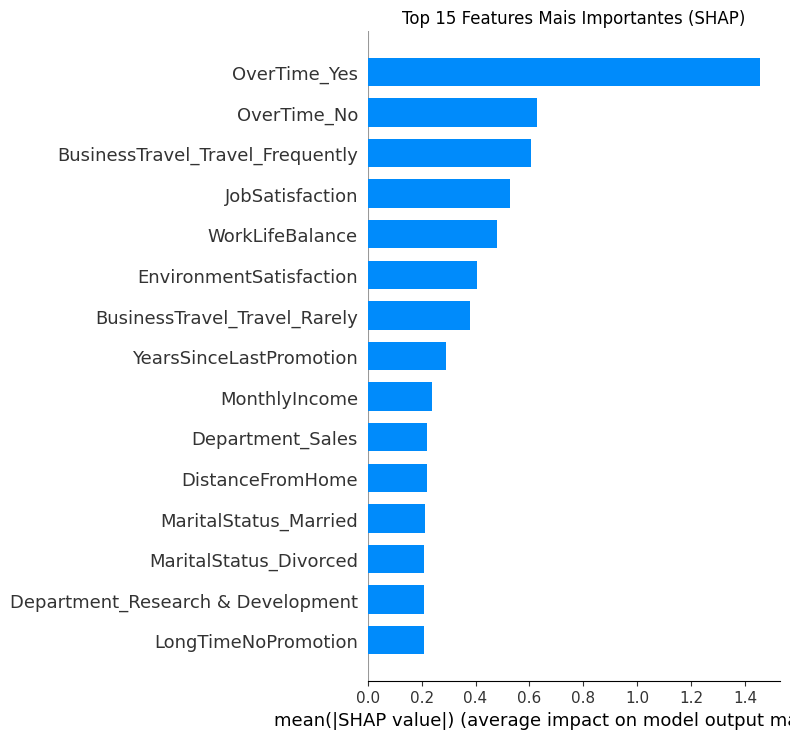

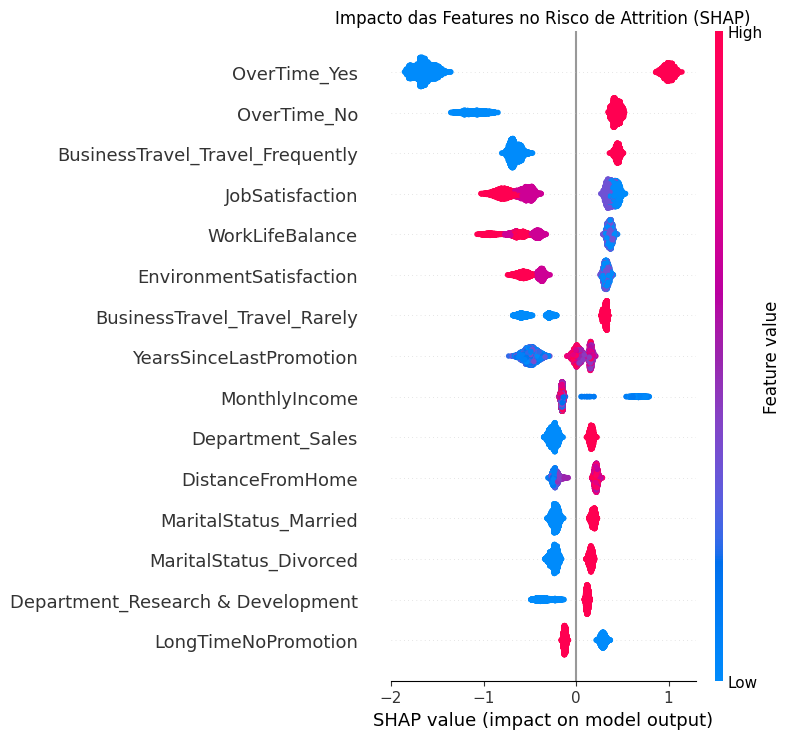

Análise SHAP concluída!


In [0]:
import shap

print("Calculando valores SHAP (pode demorar alguns minutos)...")

# Usando uma amostra menor pra não travar o cluster
sample_size = 5000
X_test_sample = X_test.sample(n=sample_size, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sample)

# Gráfico 1: importância global das features
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar",
                  max_display=15, show=False)
plt.title('Top 15 Features Mais Importantes (SHAP)')
plt.tight_layout()
plt.show()

# Gráfico 2: impacto de cada feature (positivo/negativo)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, max_display=15, show=False)
plt.title('Impacto das Features no Risco de Attrition (SHAP)')
plt.tight_layout()
plt.show()

print("Análise SHAP concluída!")


=== ANÁLISE DE FAIRNESS ===

Fairness por Gênero:
  Gender_Female: TPR=0.570, FPR=0.173, n=64663
  Gender_Male: TPR=0.561, FPR=0.176, n=64533

Fairness por Faixa Etária:
  AgeGroup_18-25: TPR=0.706, FPR=0.289, n=6392
  AgeGroup_26-35: TPR=0.622, FPR=0.217, n=17706
  AgeGroup_36-45: TPR=0.561, FPR=0.172, n=28238
  AgeGroup_46-55: TPR=0.530, FPR=0.159, n=38620
  AgeGroup_56-65: TPR=0.536, FPR=0.157, n=38240


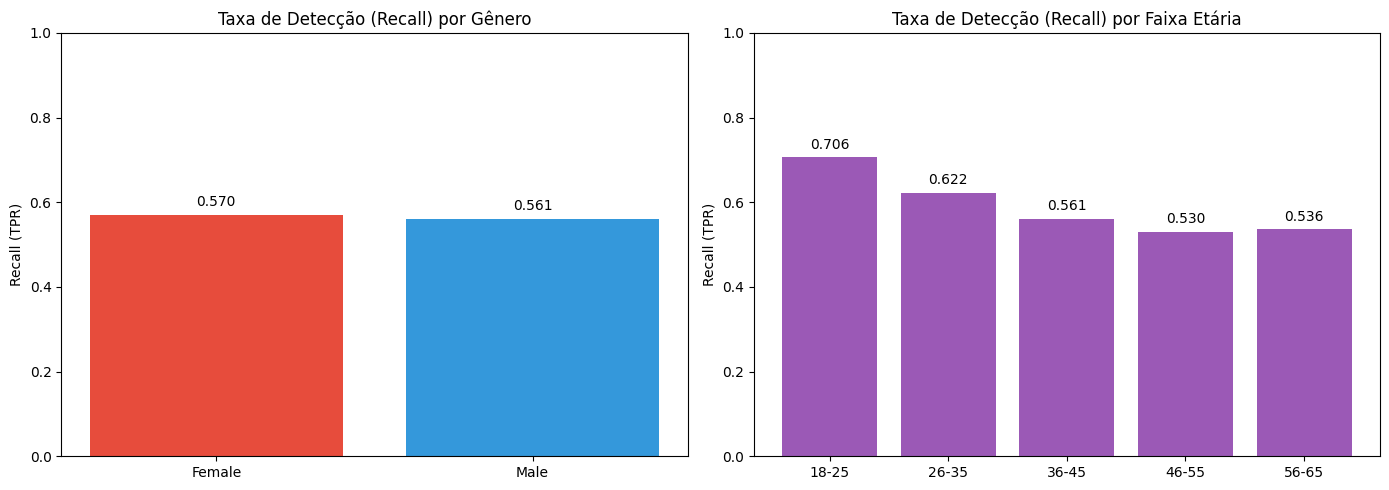

In [0]:
print("\n=== ANÁLISE DE FAIRNESS ===")

y_proba_best = best_model.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_proba_best >= 0.25).astype(int)

X_test_analysis = X_test.copy()
X_test_analysis['Attrition_Real'] = y_test.values
X_test_analysis['Attrition_Previsto'] = y_pred_optimal
X_test_analysis['Probabilidade'] = y_proba_best

# Fairness por Gênero
gender_col = [c for c in X_test_analysis.columns if 'Gender' in c]
print("\nFairness por Gênero:")
for col in gender_col:
    group = X_test_analysis[X_test_analysis[col] == 1]
    if len(group) > 0:
        tpr = recall_score(group['Attrition_Real'], group['Attrition_Previsto'], zero_division=0)
        fpr_val = (((group['Attrition_Previsto'] == 1) & (group['Attrition_Real'] == 0)).sum() /
                   (group['Attrition_Real'] == 0).sum())
        print(f"  {col}: TPR={tpr:.3f}, FPR={fpr_val:.3f}, n={len(group)}")

# Fairness por Faixa Etária
age_cols = [c for c in X_test_analysis.columns if 'AgeGroup' in c]
print("\nFairness por Faixa Etária:")
for col in age_cols:
    group = X_test_analysis[X_test_analysis[col] == 1]
    if len(group) > 0:
        tpr = recall_score(group['Attrition_Real'], group['Attrition_Previsto'], zero_division=0)
        fpr_val = (((group['Attrition_Previsto'] == 1) & (group['Attrition_Real'] == 0)).sum() /
                   max((group['Attrition_Real'] == 0).sum(), 1))
        print(f"  {col}: TPR={tpr:.3f}, FPR={fpr_val:.3f}, n={len(group)}")

# Visualização comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: TPR por gênero
tpr_gender = {}
for col in gender_col:
    group = X_test_analysis[X_test_analysis[col] == 1]
    if len(group) > 0:
        tpr_gender[col.replace('Gender_', '')] = recall_score(
            group['Attrition_Real'], group['Attrition_Previsto'], zero_division=0)

axes[0].bar(tpr_gender.keys(), tpr_gender.values(), color=['#e74c3c', '#3498db'])
axes[0].set_title('Taxa de Detecção (Recall) por Gênero')
axes[0].set_ylabel('Recall (TPR)')
axes[0].set_ylim(0, 1)
for i, (k, v) in enumerate(tpr_gender.items()):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# Gráfico 2: TPR por faixa etária
tpr_age = {}
for col in age_cols:
    group = X_test_analysis[X_test_analysis[col] == 1]
    if len(group) > 0:
        tpr_age[col.replace('AgeGroup_', '')] = recall_score(
            group['Attrition_Real'], group['Attrition_Previsto'], zero_division=0)

axes[1].bar(tpr_age.keys(), tpr_age.values(), color='#9b59b6')
axes[1].set_title('Taxa de Detecção (Recall) por Faixa Etária')
axes[1].set_ylabel('Recall (TPR)')
axes[1].set_ylim(0, 1)
for i, (k, v) in enumerate(tpr_age.items()):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()


=== ANÁLISE DE CORRELAÇÕES ===


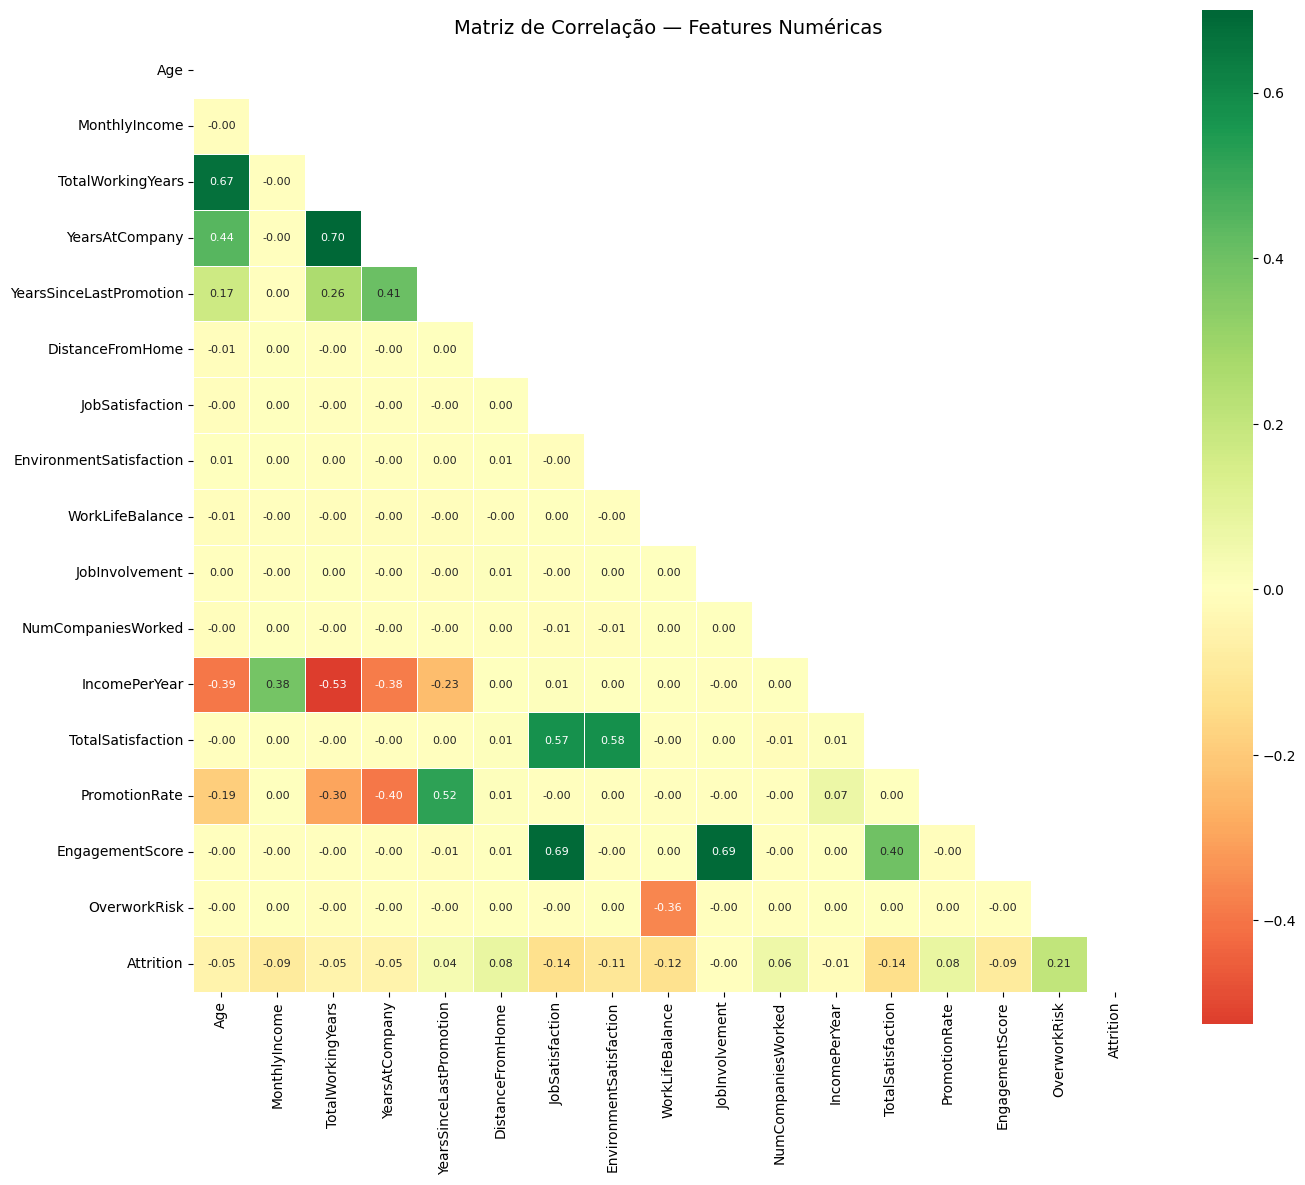


Top correlações com Attrition:
OverworkRisk               0.206553
TotalSatisfaction         -0.142121
JobSatisfaction           -0.135719
WorkLifeBalance           -0.124137
EnvironmentSatisfaction   -0.107917
EngagementScore           -0.093511
MonthlyIncome             -0.092923
PromotionRate              0.080571
DistanceFromHome           0.080377
NumCompaniesWorked         0.063259


In [0]:
print("\n=== ANÁLISE DE CORRELAÇÕES ===")

# Selecionando só colunas numéricas originais (sem as dummies, fica ilegível)
numeric_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                'YearsSinceLastPromotion', 'DistanceFromHome', 'JobSatisfaction',
                'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement',
                'NumCompaniesWorked', 'IncomePerYear', 'TotalSatisfaction',
                'PromotionRate', 'EngagementScore', 'OverworkRisk']

# Adicionando Attrition pra ver correlação com o target
corr_df = X_test_analysis[numeric_cols].copy()
corr_df['Attrition'] = y_test.values

corr_matrix = corr_df.corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de Correlação — Features Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlações com Attrition
print("\nTop correlações com Attrition:")
attrition_corr = corr_matrix['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)
print(attrition_corr.head(10).to_string())

In [0]:
from sklearn.ensemble import VotingClassifier

print("\n=== ENSEMBLE METHOD: VOTING CLASSIFIER ===")

voting_clf = VotingClassifier(
    estimators=[
        ('lgbm', optimized_models['LightGBM']),
        ('xgb', optimized_models['XGBoost']),
        ('rf', optimized_models['Random Forest'])
    ],
    voting='soft'
)

voting_clf.fit(X_train_balanced, y_train_balanced)

y_pred_voting = voting_clf.predict(X_test)
y_proba_voting = voting_clf.predict_proba(X_test)[:, 1]

roc_auc_voting = roc_auc_score(y_test, y_proba_voting)
f1_voting = f1_score(y_test, y_pred_voting)

print(f"Voting Classifier — ROC-AUC: {roc_auc_voting:.4f} | F1: {f1_voting:.4f}")
print("\nComparação final:")

comparison = optimized_results_df.copy()
voting_row = pd.DataFrame([{
    'Model': 'Voting Classifier',
    'Test_ROC_AUC': roc_auc_voting,
    'Test_F1_Score': f1_voting
}])
comparison = pd.concat([comparison, voting_row], ignore_index=True)
comparison = comparison.sort_values('Test_ROC_AUC', ascending=False)
print(comparison.to_string(index=False))


=== ENSEMBLE METHOD: VOTING CLASSIFIER ===
Voting Classifier — ROC-AUC: 0.7774 | F1: 0.2687

Comparação final:
            Model  Test_ROC_AUC  Test_F1_Score
         LightGBM      0.782376       0.271965
Voting Classifier      0.777354       0.268660
          XGBoost      0.770281       0.292688
    Random Forest      0.768724       0.242013



=== ANÁLISE DE ERRO DETALHADA ===
Falsos Negativos (perdemos, ia sair): 9222
Falsos Positivos (alarme falso, ficou): 18859
Verdadeiros Positivos (acertamos, ia sair): 12010

Perfil médio — Falsos Negativos (quem o modelo PERDEU):
Age                   47.17
MonthlyIncome      10591.40
JobSatisfaction        2.48
EngagementScore        2.71
OverworkRisk           0.11
dtype: float64

Perfil médio — Verdadeiros Positivos (quem o modelo ACERTOU):
Age                  44.90
MonthlyIncome      8360.64
JobSatisfaction       1.90
EngagementScore       2.52
OverworkRisk          0.45
dtype: float64


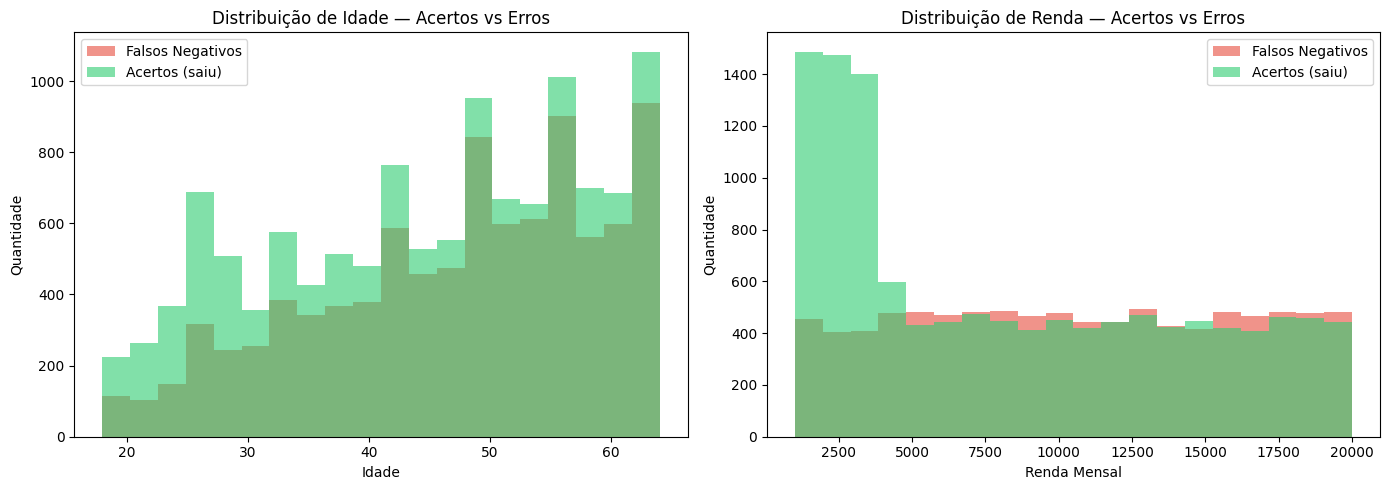

In [0]:
print("\n=== ANÁLISE DE ERRO DETALHADA ===")

y_proba_best = best_model.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_proba_best >= 0.25).astype(int)

X_test_err = X_test[['Age', 'MonthlyIncome', 'TotalWorkingYears',
                      'YearsAtCompany', 'JobSatisfaction',
                      'DistanceFromHome', 'EngagementScore',
                      'PromotionRate', 'OverworkRisk']].copy()
X_test_err['Attrition_Real'] = y_test.values
X_test_err['Attrition_Previsto'] = y_pred_optimal

# Separando os tipos de erro
falsos_negativos = X_test_err[(X_test_err['Attrition_Real'] == 1) & (X_test_err['Attrition_Previsto'] == 0)]
falsos_positivos = X_test_err[(X_test_err['Attrition_Real'] == 0) & (X_test_err['Attrition_Previsto'] == 1)]
acertos_saiu    = X_test_err[(X_test_err['Attrition_Real'] == 1) & (X_test_err['Attrition_Previsto'] == 1)]

print(f"Falsos Negativos (perdemos, ia sair): {len(falsos_negativos)}")
print(f"Falsos Positivos (alarme falso, ficou): {len(falsos_positivos)}")
print(f"Verdadeiros Positivos (acertamos, ia sair): {len(acertos_saiu)}")

print("\nPerfil médio — Falsos Negativos (quem o modelo PERDEU):")
print(falsos_negativos[['Age', 'MonthlyIncome', 'JobSatisfaction',
                         'EngagementScore', 'OverworkRisk']].mean().round(2))

print("\nPerfil médio — Verdadeiros Positivos (quem o modelo ACERTOU):")
print(acertos_saiu[['Age', 'MonthlyIncome', 'JobSatisfaction',
                     'EngagementScore', 'OverworkRisk']].mean().round(2))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de idade por tipo de erro
axes[0].hist(falsos_negativos['Age'], bins=20, alpha=0.6, label='Falsos Negativos', color='#e74c3c')
axes[0].hist(acertos_saiu['Age'], bins=20, alpha=0.6, label='Acertos (saiu)', color='#2ecc71')
axes[0].set_title('Distribuição de Idade — Acertos vs Erros')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Quantidade')
axes[0].legend()

# Distribuição de renda por tipo de erro
axes[1].hist(falsos_negativos['MonthlyIncome'], bins=20, alpha=0.6, label='Falsos Negativos', color='#e74c3c')
axes[1].hist(acertos_saiu['MonthlyIncome'], bins=20, alpha=0.6, label='Acertos (saiu)', color='#2ecc71')
axes[1].set_title('Distribuição de Renda — Acertos vs Erros')
axes[1].set_xlabel('Renda Mensal')
axes[1].set_ylabel('Quantidade')
axes[1].legend()

plt.tight_layout()
plt.show()